# Test the definition of a dual-process 3AFC linear ballistic accumulator model

This model assumes a fixed-speed process and a variable-speed process that may both contribute to a correct choice (accumulators 1 and 2) and a background process that leads to incorrect choices (accumulator 3).

In [1]:
import os
import numpy as np
from scipy import integrate
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from devreact import model
from devreact import figures

%matplotlib inline
figures.set_style()

## Generate data

In [2]:
rng = np.random.default_rng()
nt = 1000000
n = np.repeat([1, 2], int(nt / 2))
s = 1
τ = 0.5
A = 4
b = 5
v1 = 3
v2 = 4
r = 0.5
v3 = 2
v4 = 1.5
sim_response = model.random_dual(n, s, τ, A, b, v1, v2, r, v3, v4, rng, size=(nt, 2))

## Evaluate PDF

In [3]:
# set times and responses to evaluate
i = 100  # number of times
j = 2  # number of choices
k = 2  # trial types
max_time = 6
trial_type = np.repeat([1, 2], i * j)
response = np.tile(np.repeat(range(j), i), k)
time = np.tile(np.linspace(0, max_time, i), j * k)

sweep = pd.DataFrame(
    {
        'trial_type': trial_type,
        'response': response,
        'response_time': time,
        'pdf': np.zeros(i * j * k),
    }
)

In [4]:
f = model.function_pdf_dual()
rmat = sweep[['response', 'response_time']].to_numpy().astype('float64')
n_sweep = sweep['trial_type'].to_numpy().astype('int32')
sweep['pdf'] = f(rmat, n_sweep, s, τ, A, b, v1, v2, r, v3, v4)

### Check that integral of PDF is one

In [5]:
(
    sweep.groupby('trial_type')[['response_time', 'pdf']]
    .apply(lambda subs: integrate.trapezoid(subs['pdf'], subs['response_time']))
)

trial_type
1    0.999900
2    0.999975
dtype: float64

## Compare generated data to PDF

In [6]:
pdf_kwargs = {'x': 'response_time', 'y': 'pdf', 'color': 'C1'}

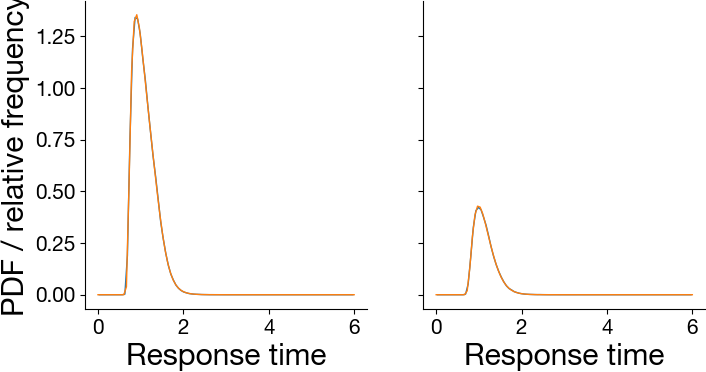

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(8, 4), sharey=True)

ind = (sim_response[:, 0] == 1) & (n == 1)
hist, edges = np.histogram(sim_response[ind, 1], range=(0, 6), bins=100)
centers = edges[:-1] + (edges[1:] - edges[:-1]) / 2
ax[0].plot(centers, hist / 30000)
sns.lineplot(
    data=sweep.query('trial_type == 1 and response == 1'), 
    ax=ax[0],
    **pdf_kwargs,
)
ax[0].set(ylabel='PDF / relative frequency', xlabel='Response time')

ind = (sim_response[:, 0] == 0) & (n == 1)
hist, edges = np.histogram(sim_response[ind, 1], range=(0, 6), bins=100)
centers = edges[:-1] + (edges[1:] - edges[:-1]) / 2
ax[1].plot(centers, hist / 30000)
sns.lineplot(
    data=sweep.query('trial_type == 1 and response == 0'),
    ax=ax[1],
    **pdf_kwargs,
)
ax[1].set(xlabel='Response time');

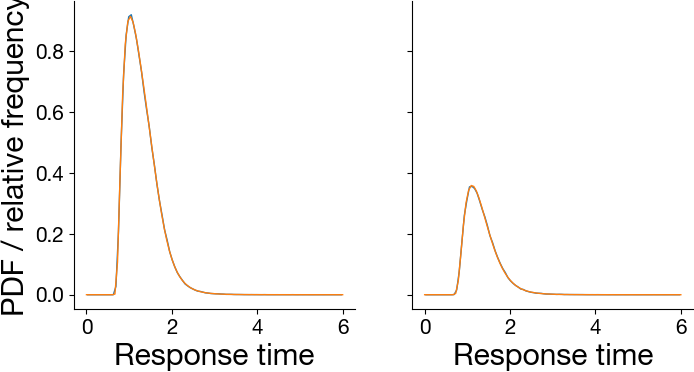

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(8, 4), sharey=True)

ind = (sim_response[:, 0] == 1) & (n == 2)
hist, edges = np.histogram(sim_response[ind, 1], range=(0, 6), bins=100)
centers = edges[:-1] + (edges[1:] - edges[:-1]) / 2
ax[0].plot(centers, hist / 30000)
sns.lineplot(
    data=sweep.query('trial_type == 2 and response == 1'), 
    ax=ax[0],
    **pdf_kwargs,
)
ax[0].set(ylabel='PDF / relative frequency', xlabel='Response time')

ind = (sim_response[:, 0] == 0) & (n == 2)
hist, edges = np.histogram(sim_response[ind, 1], range=(0, 6), bins=100)
centers = edges[:-1] + (edges[1:] - edges[:-1]) / 2
ax[1].plot(centers, hist / 30000)
sns.lineplot(
    data=sweep.query('trial_type == 2 and response == 0'),
    ax=ax[1],
    **pdf_kwargs,
)
ax[1].set(xlabel='Response time');

In [9]:
%load_ext watermark
%watermark -v -iv

Python implementation: CPython
Python version       : 3.13.6
IPython version      : 9.12.0

devreact  : 0.1.0
matplotlib: 3.10.8
numpy     : 2.4.4
pandas    : 3.0.2
scipy     : 1.17.1
seaborn   : 0.13.2

